# Requirement 3 — Best-of-Both-Worlds Bidding with a Primal-Dual Method

**Task (from `project.pdf`).** Design a bidding strategy for *multiple campaigns* under a budget constraint using a **primal-dual method**. The strategy must work well both in the *stochastic* environment of Requirement 2 and in a *highly non-stationary* environment (a non-stochastic sequence of highest competing bids, e.g. sampled from distributions that change quickly over time). For this requirement we are allowed **full feedback**: after each round we observe the highest competing bid $m_{t,i}$ of *every* campaign $i$.

**What we build in this notebook**

1. Two multi-campaign environments: stochastic (as in Requirement 2) and highly non-stationary (piecewise-constant distributions that change abruptly every segment).
2. A primal-dual agent following Lecture 8 / Practical 08:
   - **primal** regret maximizer: Hedge over super-arms $(S, b_S)$,
   - **dual** regret minimizer: online gradient descent (OGD) on the Lagrange multiplier $\lambda \in [0, 1/\rho]$, with $\rho = B/T$ fixed (as in the lecture algorithm) and $\lambda_0 = 0$.
3. Baselines: the LP clairvoyant $OPT_S$ (stochastic), the in-hindsight LP $OPT_A$, and the worst-case benchmark $\rho\,OPT_A$ (adversarial / non-stationary).
4. A Combinatorial-UCB baseline (Lecture 8's UCB-Bidding, bandit feedback) for comparison, giving the "four curves, two environments" cross-table.

The main references are Lecture 7 (*Learning in truthful auctions with budget constraints*), Lecture 8 (*Learning in non-truthful auctions with budget constraints*), Practical Session 07 and Practical Session 08.

## Setting and action space

At each round $t \in [T]$:

1. We choose a bid $b_{t,i}$ for each campaign $i$ (or opt out of some campaigns).
2. The competitors realize the highest competing bid $m_{t,i}$ for each campaign.
3. We win campaign $i$ iff $b_{t,i} \ge m_{t,i}$; then we get utility $v_i - b_{t,i}$ and pay cost $b_{t,i}$.
4. We observe the set of won auctions; **in this requirement we also observe all $m_{t,i}$ (full feedback)**.

Because of the conflict graph, the set of campaigns we bid on in a round must be an **independent set** of the graph. Therefore, as in Requirement 2, the natural *action* is a **super-arm**:

$$
a = (S, b_S), \qquad S \in \mathcal{I}(G), \quad b_S \in \mathcal{B}^{|S|},
$$

where $\mathcal{I}(G)$ is the set of independent sets and $\mathcal{B}$ is the discrete bid set. The empty super-arm $(\emptyset, \emptyset)$ means "bid on nothing" and is always feasible.

For a super-arm $a$ its realized round-utility and round-cost are

$$
f_t(a) = \sum_{i \in S} (v_i - b_i)\,\mathbb{1}\{b_i \ge m_{t,i}\},
\qquad
c_t(a) = \sum_{i \in S} b_i\,\mathbb{1}\{b_i \ge m_{t,i}\}.
$$

Because $|S|$ can be larger than one, the realized cost of a super-arm can exceed $1$ (up to $\sum_{i\in S} b_i$); we handle this explicitly with an *affordability safeguard* in both agents (a super-arm is only played when its worst-case payment fits the remaining budget).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations, product
from scipy import optimize

In [2]:
# ============================================================
# Problem parameters (same spirit as requirement_2.ipynb)
# ============================================================
T = 2000                      # number of rounds
n_campaigns = 3
my_valuations = np.array([0.4, 0.6, 0.8])   # v_i for each campaign
n_competitors = [2, 3, 5]     # competing bidders per campaign

# Discrete bid set (the same grid for every campaign)
available_bids = np.linspace(0, 1, 11)
n_bids = len(available_bids)
bid_to_index = {round(b, 8): i for i, b in enumerate(available_bids)}

# Shared budget: B is chosen so that rho = B/T is *binding*
B = 100
rho = B / T

# Conflict graph: campaigns 2 and 3 (0-indexed: 1 and 2) are non-compatible,
# i.e. they cannot be bid on in the same round.
conflict_edges = [(1, 2)]

# ---------- super-arms: (independent set, bid vector) ----------
def enumerate_independent_sets(n_campaigns, conflict_edges):
    conflicts = set(conflict_edges)

    def is_independent(subset):
        subset = set(subset)
        return not any({i, j} <= subset for i, j in conflicts)

    return [subset
            for size in range(n_campaigns + 1)
            for subset in combinations(range(n_campaigns), size)
            if is_independent(subset)]

def build_super_arms(independent_sets, available_bids, my_valuations, eps=1e-6):
    super_arms = []
    for subset in independent_sets:
        if not subset:
            super_arms.append((subset, ()))          # empty super-arm = opt-out
        else:
            # only "good" bids: b <= v_i (higher bids give negative utility)
            valid_bids = [[b for b in available_bids if b <= my_valuations[i] + eps]
                          for i in subset]
            super_arms.extend((subset, bids) for bids in product(*valid_bids))
    return super_arms

independent_sets = enumerate_independent_sets(n_campaigns, conflict_edges)
super_arms = build_super_arms(independent_sets, available_bids, my_valuations)
K = len(super_arms)
empty_idx = next(k for k, (S, _) in enumerate(super_arms) if len(S) == 0)

print("Independent sets (0-indexed):", independent_sets)
print("Number of super-arms:", K)
print("rho =", rho, " lambda_max =", 1 / rho)

Independent sets (0-indexed): [(), (0,), (1,), (2,), (0, 1), (0, 2)]
Number of super-arms: 102
rho = 0.05  lambda_max = 20.0


## Environments

**Stochastic environment.** As in Requirement 2, each campaign $i$ has $k_i$ competitors whose bids are i.i.d. $\mathrm{Uniform}(0,1)$; hence

$$
m_{t,i} \sim \mathrm{Beta}(k_i, 1), \qquad \mathbb{P}(b \ge m_i) = b^{k_i}.
$$

**Highly non-stationary environment.** The horizon is partitioned into segments; in each segment the *distribution* of the competing bids is fixed, and it changes abruptly from segment to segment ("sampled from a distribution that changes quickly over time"). Concretely, in segment $s$ the competitors of campaign $i$ bid $\mathrm{Uniform}(0, u_{s,i})$, so the distribution jumps every $T / \text{n\_segments}$ rounds. The sequence is generated with a fixed seed, so it is a fixed (oblivious-adversarial) sequence across trials.

Notice that the *environment* changes at every segment, while the *optimal action* changes only when the distributional change is large enough to alter the best bid (e.g., campaign 3 switches between high bids around 0.7 and low bids around 0.3–0.5, whereas campaign 1's best grid bid stays at 0.3 throughout). This is the piecewise-constant, abruptly-changing structure used throughout the non-stationary part of the course.

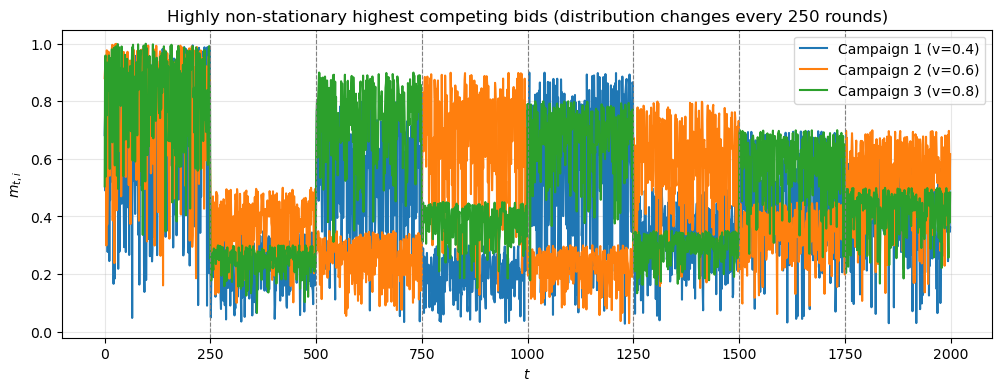

In [3]:
# ============================================================
# Environments
# ============================================================
def stochastic_competing_bids(seed, n_competitors, T):
    """i.i.d. rounds: m_{t,i} = max of k_i Uniform(0,1) ~ Beta(k_i,1)."""
    rng = np.random.default_rng(seed)
    m = np.empty((len(n_competitors), T))
    for i, k in enumerate(n_competitors):
        m[i] = rng.uniform(0, 1, size=(k, T)).max(axis=0)
    return m

# Segment scales for the non-stationary environment (rows = segments).
# In segment s, campaign i's competitors bid Uniform(0, segment_scales[s, i]).
n_segments = 8
segment_scales = np.array([
    [1.00, 1.00, 1.00],
    [0.35, 0.50, 0.30],
    [0.80, 0.35, 0.90],
    [0.30, 0.90, 0.45],
    [0.90, 0.30, 0.80],
    [0.50, 0.80, 0.35],
    [0.70, 0.45, 0.70],
    [0.60, 0.70, 0.50],
])

def nonstationary_competing_bids(seed, n_competitors, T, segment_scales):
    """Fixed (oblivious-adversarial) sequence with abrupt distribution changes."""
    rng = np.random.default_rng(seed)
    n_segments, n_campaigns = segment_scales.shape
    seg_len = T // n_segments
    m = np.empty((n_campaigns, T))
    for s in range(n_segments):
        start, end = s * seg_len, (s + 1) * seg_len
        for i in range(n_campaigns):
            u = segment_scales[s, i]
            m[i, start:end] = rng.uniform(0, u, size=(n_competitors[i], seg_len)).max(axis=0)
    return m

# Visualize the non-stationary sequence
m_ns = nonstationary_competing_bids(seed=123, n_competitors=n_competitors,
                                    T=T, segment_scales=segment_scales)
plt.figure(figsize=(12, 4))
for i in range(n_campaigns):
    plt.plot(m_ns[i], label=f"Campaign {i+1} (v={my_valuations[i]})")
for s in range(1, n_segments):
    plt.axvline(s * (T // n_segments), color="gray", ls="--", lw=0.8)
plt.xlabel("$t$")
plt.ylabel("$m_{t,i}$")
plt.title("Highly non-stationary highest competing bids (distribution changes every 250 rounds)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Full feedback: realized utility/cost of every super-arm

Since we observe $m_t = (m_{t,1}, \dots, m_{t,N})$ after round $t$, we can compute $f_t(a)$ and $c_t(a)$ for **every** super-arm $a$. This turns the primal problem into an *adversarial expert problem* (full feedback), for which Hedge is the natural regret minimizer (Lecture 8).

In [4]:
# ============================================================
# Full-feedback oracle
# ============================================================
def super_arm_fc(m_t, super_arms, my_valuations, available_bids, bid_to_index):
    """Given the vector m_t (highest competing bid of each campaign), return
    f_t(a) and c_t(a) for EVERY super-arm a."""
    win = available_bids[None, :] >= m_t[:, None]                    # (N, Kb)
    rew = (my_valuations[:, None] - available_bids[None, :]) * win   # (N, Kb)
    cost = available_bids[None, :] * win                             # (N, Kb)

    f_vec = np.zeros(len(super_arms))
    c_vec = np.zeros(len(super_arms))
    for k, (subset, bids) in enumerate(super_arms):
        if not subset:
            continue
        idx = np.array([bid_to_index[round(b, 8)] for b in bids])
        subset_arr = np.array(subset)
        f_vec[k] = rew[subset_arr, idx].sum()
        c_vec[k] = cost[subset_arr, idx].sum()
    return f_vec, c_vec

# Largest possible payment of a super-arm in one round (if every campaign in S
# wins). It can exceed 1 because |S| can be larger than one; both agents use it
# for the affordability safeguard (never play what the budget cannot cover).
max_pay = np.array([sum(bids) for _, bids in super_arms])
print("Largest possible one-round payment of any super-arm:", max_pay.max())

Largest possible one-round payment of any super-arm: 1.2000000000000002


## The primal-dual method (Lecture 8 / Practical 08)

We Lagrangify the budget constraint $\mathbb{E}[c_t] \le \rho$ (with $\rho = B/T$ fixed):

$$
L(\gamma, \lambda, f_t, c_t) = \mathbb{E}_{a \sim \gamma}[f_t(a)] - \lambda \left( \mathbb{E}_{a \sim \gamma}[c_t(a)] - \rho \right).
$$

The agent plays a **two-player game**:

- the **primal player** chooses $\gamma \in \Delta(\mathcal{A})$ to *maximize* $L$;
- the **dual player** chooses $\lambda \in [0, 1/\rho]$ to *minimize* $L$.

**Primal regret minimizer — Hedge.** For a fixed $\lambda_t$, maximizing $L$ over super-arms is equivalent to maximizing the per-arm reward

$$
r_t(a) = f_t(a) - \lambda_t\, c_t(a).
$$

We feed Hedge with the losses $1 - \text{normalized}(r_t(a)) \in [0,1]$, where the normalization is performed *per round* on the realized Lagrangian rewards. (This is a practical implementation detail: the worst-case bounds on $r_t(a)$ are much looser than the realized rewards, and a fixed worst-case normalization makes Hedge learn impractically slowly. The formal guarantees below apply to the canonical algorithm with a fixed bounded loss range.) Hedge maintains weights $w_{t+1}(a) = w_t(a)\,e^{-\eta \ell_t(a)}$ and plays $a_t \sim x_t = w_t / \sum w_t$.

**Dual regret minimizer — OGD with fixed $\rho$.** The dual loss is $\ell^D_t(\lambda) = \lambda(\rho - \mathbb{E}_{a\sim x_t}[c_t(a)])$, so one gradient step gives

$$
\lambda_{t+1} = \Pi_{[0,1/\rho]}\Big(\lambda_t + \eta_\lambda \big(\mathbb{E}_{a \sim x_t}[c_t(a)] - \rho\big)\Big),
$$

starting from $\lambda_0 = 0$, as in the lecture algorithm. We use the expected cost under $x_t$ (the full-feedback variant of Practical 08); the lecture pseudocode uses the realized cost of the played bid, which is the bandit variant.

**Hard budget.** The algorithm stops bidding when the remaining budget is below $1$, and a super-arm is only played if its worst-case payment $\sum_{i\in S} b_i$ fits the remaining budget (affordability safeguard; needed because a super-arm's realized cost can exceed $1$).

**Why "best of both worlds".** The same canonical algorithm guarantees (Lecture 8; Practical 08):

- stochastic environment: regret $\tilde{O}(\sqrt{T})$ w.r.t. the LP clairvoyant $OPT_S$ (Badanidiyuru et al. 2018; Balseiro & Gur 2019 for the truthful multiplicative-pacing case);
- adversarial environment: utility at least $\rho\, T\, OPT_A - \tilde{O}(\sqrt{T})$, where $OPT_A$ is the best fixed distribution in hindsight (Castiglioni et al. 2022). No algorithm can guarantee more than a $\rho$ fraction of $OPT_A$ in the worst case.

In [5]:
# ============================================================
# Primal-dual agent (full feedback) — Lecture 8 / Practical 08
# ============================================================
class PrimalDualAgent:
    """Bidding via primal-dual method.

    Primal (maximizer of the Lagrangian): Hedge over super-arms with
        r_t(a) = f_t(a) - lambda_t * c_t(a).
    Dual (minimizer): online gradient descent on lambda in [0, 1/rho],
        with FIXED rho = B/T and lambda_0 = 0 (as in the lecture algorithm).
    """

    def __init__(self, super_arms, empty_idx, T, B):
        self.super_arms = super_arms
        self.empty_idx = empty_idx
        self.K = len(super_arms)
        self.T = T
        self.B = B
        self.rho = B / T
        self.lambda_max = 1 / self.rho
        self.max_pay = np.array([sum(bids) for _, bids in super_arms])

        self.weights = np.ones(self.K)
        self.x_t = np.ones(self.K) / self.K
        self.lmbd = 0.0                       # lambda_0 = 0 (lecture)

        self.hedge_eta = np.sqrt(np.log(self.K) / self.T)
        self.ogd_eta = 1 / np.sqrt(self.T)

        self.budget = B
        self.t = 0
        self.lmbd_history = []

    def pull_arm(self):
        if self.budget < 1:                   # hard budget constraint
            return self.empty_idx
        self.x_t = self.weights / self.weights.sum()
        a = np.random.choice(self.K, p=self.x_t)
        # affordability safeguard: worst-case payment of a must fit the budget
        if self.max_pay[a] > self.budget:
            return self.empty_idx
        return a

    def update(self, f_vec, c_vec, a_t):
        # --- primal: Hedge maximizes f(a) - lambda*c(a) ---
        primal_reward = f_vec - self.lmbd * c_vec
        # Practical normalization to [0,1] using the per-round range of the
        # Lagrangian rewards (fixed worst-case bounds are far looser than the
        # realized rewards and make Hedge learn too slowly).
        r_min = primal_reward.min()
        r_max = primal_reward.max()
        span = r_max - r_min
        if span < 1e-12:
            loss = 0.5 * np.ones_like(primal_reward)              # all arms equal
        else:
            normalized = (primal_reward - r_min) / span           # rewards in [0,1]
            loss = 1.0 - normalized                               # losses in [0,1]
        self.weights *= np.exp(-self.hedge_eta * loss)
        self.weights /= self.weights.max()                        # numerical stability

        # --- dual: OGD with FIXED rho, using the expected cost of x_t ---
        expected_cost = c_vec @ self.x_t
        self.lmbd = np.clip(self.lmbd + self.ogd_eta * (expected_cost - self.rho),
                            0.0, self.lambda_max)
        self.lmbd_history.append(self.lmbd)

        # --- hard budget ---
        self.budget -= c_vec[a_t]
        self.t += 1

## Baselines

**Stochastic environment — $OPT_S$.** The clairvoyant knows the true distributions and solves

$$
\max_{\gamma \in \Delta(\mathcal{A})} \sum_a \gamma(a)\, \bar f(a)
\quad \text{s.t.} \quad
\sum_a \gamma(a)\, \bar c(a) \le \rho,
$$

with $\bar f(a) = \sum_{i \in S}(v_i - b_i)\,b_i^{k_i}$ and $\bar c(a) = \sum_{i \in S} b_i\, b_i^{k_i}$. This is a linear program.

**Adversarial / non-stationary environment — $OPT_A$.** The baseline is the *best fixed distribution in hindsight*: the same LP, but with the **empirical** win probabilities computed on the realized sequence $m_1, \dots, m_T$ (exactly as in Practical 08). In the worst case no algorithm can beat $\rho\,OPT_A$, so the practical/lecture convention is to plot the *gap to the worst-case guarantee*

$$
G_A(t) = \rho\, t\, OPT_A - \sum_{s\le t} f_s(a_s),
$$

which may be negative. We additionally report the *standard* regret w.r.t. $OPT_A$,

$$
R_A(T) = T\, OPT_A - \sum_{t\in[T]} f_t(a_t),
$$

so both course conventions are explicit.

In [6]:
# ============================================================
# Baselines (LP clairvoyants)
# ============================================================
def compute_clairvoyant_lp(super_arm_rewards, super_arm_costs, rho):
    """Best fixed distribution over super-arms with expected cost <= rho."""
    res = optimize.linprog(-super_arm_rewards,
                           A_ub=[super_arm_costs], b_ub=[rho],
                           A_eq=[np.ones(len(super_arm_rewards))], b_eq=[1],
                           bounds=(0, 1), method="highs")
    if not res.success:
        raise ValueError(res.message)
    return res.x, -res.fun

def stochastic_clairvoyant(super_arms, my_valuations, n_competitors,
                           available_bids, bid_to_index, rho):
    """OPT_S: LP with the TRUE win probabilities P_i(b) = b^{k_i}."""
    win_prob = np.array([available_bids ** k for k in n_competitors])
    rewards = np.zeros(len(super_arms))
    costs = np.zeros(len(super_arms))
    for k, (subset, bids) in enumerate(super_arms):
        if not subset:
            continue
        idx = np.array([bid_to_index[round(b, 8)] for b in bids])
        subset_arr = np.array(subset)
        p = win_prob[subset_arr, idx]
        rewards[k] = ((my_valuations[subset_arr] - np.array(bids)) * p).sum()
        costs[k] = (np.array(bids) * p).sum()
    return compute_clairvoyant_lp(rewards, costs, rho)

def adversarial_clairvoyant(m_seq, super_arms, my_valuations,
                            available_bids, bid_to_index, rho):
    """OPT_A: LP with EMPIRICAL win probabilities over the realized sequence."""
    T = m_seq.shape[1]
    rewards = np.zeros(len(super_arms))
    costs = np.zeros(len(super_arms))
    for t in range(T):
        f_vec, c_vec = super_arm_fc(m_seq[:, t], super_arms, my_valuations,
                                    available_bids, bid_to_index)
        rewards += f_vec
        costs += c_vec
    return compute_clairvoyant_lp(rewards / T, costs / T, rho)

gamma_s, OPT_S = stochastic_clairvoyant(super_arms, my_valuations, n_competitors,
                                        available_bids, bid_to_index, rho)
print("OPT_S (per-round expected utility):", OPT_S)

# expected cost of OPT_S (sanity check: should be ~rho when the budget binds)
win_prob_s = np.array([available_bids ** k for k in n_competitors])
costs_s = np.zeros(len(super_arms))
for k, (subset, bids) in enumerate(super_arms):
    if not subset:
        continue
    idx = np.array([bid_to_index[round(b, 8)] for b in bids])
    costs_s[k] = (np.array(bids) * win_prob_s[np.array(subset), idx]).sum()
print("Expected cost of OPT_S:", gamma_s @ costs_s, " rho =", rho)

OPT_S (per-round expected utility): 0.022943465045592713
Expected cost of OPT_S: 0.05  rho = 0.05


## Baseline agent for comparison: Combinatorial-UCB (Lecture 8's UCB-Bidding)

We also run a **Combinatorial-UCB** agent with bandit feedback as a comparison baseline. It follows Lecture 8's *UCB-Bidding* algorithm:

- it keeps UCBs on utilities and LCBs on costs for every base arm $(i, b)$;
- it scores every super-arm by summing the bounds;
- every round it solves the LP over super-arms with the **fixed** per-round budget $\rho = B/T$ (no extra pacing mechanism);
- unexplored base arms get an optimistic bonus so that they are forced to be pulled.

This is the lecture version of the algorithm (without the fallback shortcut currently present in the R2 draft notebook — R2 should be aligned to this version). The agent respects the hard budget through the same affordability safeguard.

In [7]:
# ============================================================
# Combinatorial-UCB agent (Lecture 8 UCB-Bidding, bandit feedback)
# ============================================================
class CombinatorialUCBAgent:
    def __init__(self, super_arms, empty_idx, bid_to_index,
                 n_campaigns, n_bids, my_valuations, T, B):
        self.super_arms = super_arms
        self.empty_idx = empty_idx
        self.bid_to_index = bid_to_index
        self.N = n_campaigns
        self.Kb = n_bids
        self.my_valuations = my_valuations
        self.T = T
        self.B = B
        self.rho = B / T
        self.max_pay = np.array([sum(bids) for _, bids in super_arms])

        self.avg_f = np.zeros((n_campaigns, n_bids))
        self.avg_c = np.zeros((n_campaigns, n_bids))
        self.N_pulls = np.zeros((n_campaigns, n_bids))
        self.budget = B
        self.t = 0
        self.large_value = (1 + np.sqrt(2 * np.log(T))) * my_valuations.max()

    def _bounds(self):
        f_ucb = np.zeros((self.N, self.Kb))
        c_lcb = np.zeros((self.N, self.Kb))
        for i in range(self.N):
            n = self.N_pulls[i]
            pulled = n > 0
            radius = np.zeros(self.Kb)
            radius[pulled] = self.my_valuations[i] * np.sqrt(2 * np.log(self.T) / n[pulled])
            f_ucb[i] = self.avg_f[i] + radius
            f_ucb[i, ~pulled] = self.large_value
            c_lcb[i] = np.maximum(self.avg_c[i] - radius, 0.0)   # optimistic on costs
        return f_ucb, c_lcb

    def pull_arm(self):
        if self.budget < 1:
            return self.empty_idx
        f_ucb, c_lcb = self._bounds()

        F = np.zeros(len(self.super_arms))
        C = np.zeros(len(self.super_arms))
        for k, (subset, bids) in enumerate(self.super_arms):
            if not subset:
                continue
            idx = [self.bid_to_index[round(b, 8)] for b in bids]
            F[k] = f_ucb[subset, idx].sum()
            C[k] = c_lcb[subset, idx].sum()

        gamma = self._solve_lp(F, C, self.rho)      # fixed rho = B/T
        a = np.random.choice(len(self.super_arms), p=gamma)
        if self.max_pay[a] > self.budget:           # affordability safeguard
            return self.empty_idx
        return a

    def _solve_lp(self, F, C, rho):
        res = optimize.linprog(-F, A_ub=[C], b_ub=[rho],
                               A_eq=[np.ones(len(F))], b_eq=[1],
                               bounds=(0, 1), method="highs")
        if res.success and np.all(np.isfinite(res.x)):
            return res.x
        gamma = np.zeros(len(F))
        gamma[np.argmax(F)] = 1.0
        return gamma

    def update(self, S_t, bids_t, f_list, c_list):
        total_cost = 0.0
        for campaign, bid, f, c in zip(S_t, bids_t, f_list, c_list):
            j = self.bid_to_index[round(bid, 8)]
            self.N_pulls[campaign, j] += 1
            n = self.N_pulls[campaign, j]
            self.avg_f[campaign, j] += (f - self.avg_f[campaign, j]) / n
            self.avg_c[campaign, j] += (c - self.avg_c[campaign, j]) / n
            total_cost += c
        self.budget -= total_cost
        self.t += 1

## Experiment 1 — stochastic environment

We run both agents on i.i.d. rounds ($m_{t,i} \sim \mathrm{Beta}(k_i,1)$) for several trials, with the same binding budget $B=100$. Regret is measured against $OPT_S$ per round.

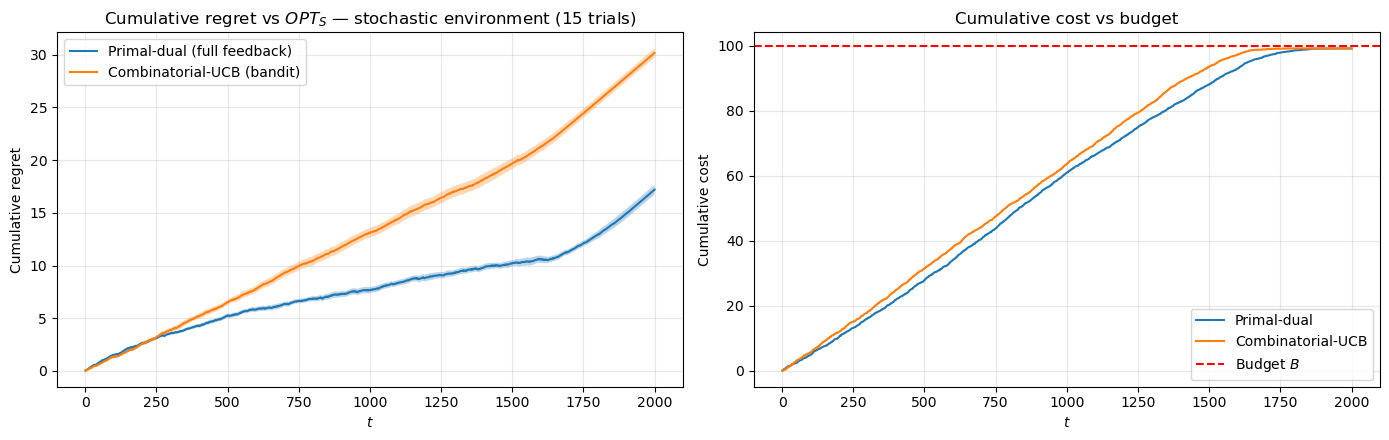

Stochastic env — final average regret: PD = 17.20, C-UCB = 30.18
Stochastic env — final average cost:   PD = 99.22, C-UCB = 99.24  (B = 100)


In [8]:
# ============================================================
# Experiment 1: stochastic environment
# ============================================================
n_trials = 15

pd_regret_stoch = []
pd_cost_stoch = []
ucb_regret_stoch = []
ucb_cost_stoch = []

for trial in range(n_trials):
    m_trial = stochastic_competing_bids(seed=trial, n_competitors=n_competitors, T=T)
    np.random.seed(trial)      # reproducible algorithm randomness

    # --- primal-dual (full feedback) ---
    pd = PrimalDualAgent(super_arms, empty_idx, T, B)
    u_pd = np.zeros(T)
    c_pd = np.zeros(T)
    for t in range(T):
        a = pd.pull_arm()
        f_vec, c_vec = super_arm_fc(m_trial[:, t], super_arms, my_valuations,
                                    available_bids, bid_to_index)
        pd.update(f_vec, c_vec, a)
        u_pd[t] = f_vec[a]
        c_pd[t] = c_vec[a]
    pd_regret_stoch.append(np.cumsum(OPT_S - u_pd))
    pd_cost_stoch.append(np.cumsum(c_pd))

    # --- combinatorial-UCB (bandit feedback) ---
    ucba = CombinatorialUCBAgent(super_arms, empty_idx, bid_to_index,
                                 n_campaigns, n_bids, my_valuations, T, B)
    u_ucb = np.zeros(T)
    c_ucb = np.zeros(T)
    for t in range(T):
        a = ucba.pull_arm()
        S, bids = super_arms[a]
        if S:
            win = available_bids[None, :] >= m_trial[:, t, None]          # (N, Kb)
            rew_t = (my_valuations[:, None] - available_bids[None, :]) * win
            cost_t = available_bids[None, :] * win
            f_list = [rew_t[i, bid_to_index[round(b, 8)]] for i, b in zip(S, bids)]
            c_list = [cost_t[i, bid_to_index[round(b, 8)]] for i, b in zip(S, bids)]
        else:
            f_list, c_list = [], []
        ucba.update(S, bids, f_list, c_list)
        u_ucb[t] = sum(f_list)
        c_ucb[t] = sum(c_list)
    ucb_regret_stoch.append(np.cumsum(OPT_S - u_ucb))
    ucb_cost_stoch.append(np.cumsum(c_ucb))

pd_regret_stoch = np.array(pd_regret_stoch)
pd_cost_stoch = np.array(pd_cost_stoch)
ucb_regret_stoch = np.array(ucb_regret_stoch)
ucb_cost_stoch = np.array(ucb_cost_stoch)

rounds = np.arange(1, T + 1)

def plot_curves(regret_pd, regret_ucb, cost_pd, cost_ucb, title, n_tr,
                ylabel="Cumulative regret"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

    ax1.plot(rounds, regret_pd.mean(axis=0), label="Primal-dual (full feedback)")
    ax1.fill_between(rounds,
                     regret_pd.mean(axis=0) - regret_pd.std(axis=0) / np.sqrt(n_tr),
                     regret_pd.mean(axis=0) + regret_pd.std(axis=0) / np.sqrt(n_tr),
                     alpha=0.3)
    ax1.plot(rounds, regret_ucb.mean(axis=0), label="Combinatorial-UCB (bandit)")
    ax1.fill_between(rounds,
                     regret_ucb.mean(axis=0) - regret_ucb.std(axis=0) / np.sqrt(n_tr),
                     regret_ucb.mean(axis=0) + regret_ucb.std(axis=0) / np.sqrt(n_tr),
                     alpha=0.3)
    ax1.set_xlabel("$t$"); ax1.set_ylabel(ylabel)
    ax1.set_title(title); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(rounds, cost_pd.mean(axis=0), label="Primal-dual")
    ax2.plot(rounds, cost_ucb.mean(axis=0), label="Combinatorial-UCB")
    ax2.axhline(B, color="red", ls="--", label="Budget $B$")
    ax2.set_xlabel("$t$"); ax2.set_ylabel("Cumulative cost")
    ax2.set_title("Cumulative cost vs budget"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_curves(pd_regret_stoch, ucb_regret_stoch, pd_cost_stoch, ucb_cost_stoch,
            f"Cumulative regret vs $OPT_S$ — stochastic environment ({n_trials} trials)", n_trials)

print(f"Stochastic env — final average regret: PD = {pd_regret_stoch.mean(axis=0)[-1]:.2f}, "
      f"C-UCB = {ucb_regret_stoch.mean(axis=0)[-1]:.2f}")
print(f"Stochastic env — final average cost:   PD = {pd_cost_stoch.mean(axis=0)[-1]:.2f}, "
      f"C-UCB = {ucb_cost_stoch.mean(axis=0)[-1]:.2f}  (B = {B})")

## Scaling check (stochastic environment)

The theory predicts regret $\tilde O(\sqrt{T})$. A single point ($R_{2000} \approx 25$) is only suggestive, so we check the growth of $R_T$ (and of $R_T/T$) over several horizons $T \in \{500, 1000, 2000, 4000\}$, keeping the per-round budget fixed ($B = \rho T$ with $\rho = 0.05$). If the regret is sublinear, $R_T/T$ should decrease as $T$ grows.

In [9]:
# ============================================================
# Scaling check: R_T and R_T/T on the stochastic environment
# ============================================================
horizons = [500, 1000, 2000, 4000]
n_trials_scale = 5

print(f"{'T':>6} {'B':>5} {'R_T (PD)':>10} {'R_T/T (PD)':>12} {'R_T (C-UCB)':>12} {'R_T/T (C-UCB)':>14}")
for T_h in horizons:
    B_h = int(round(rho * T_h))
    r_pd = []
    r_cb = []
    for seed in range(n_trials_scale):
        m_h = stochastic_competing_bids(seed=seed, n_competitors=n_competitors, T=T_h)

        np.random.seed(seed)
        pd = PrimalDualAgent(super_arms, empty_idx, T_h, B_h)
        u = 0.0
        for t in range(T_h):
            a = pd.pull_arm()
            f_vec, c_vec = super_arm_fc(m_h[:, t], super_arms, my_valuations,
                                        available_bids, bid_to_index)
            pd.update(f_vec, c_vec, a)
            u += f_vec[a]
        r_pd.append(OPT_S * T_h - u)

        np.random.seed(seed)
        ucba = CombinatorialUCBAgent(super_arms, empty_idx, bid_to_index,
                                     n_campaigns, n_bids, my_valuations, T_h, B_h)
        u = 0.0
        for t in range(T_h):
            a = ucba.pull_arm()
            S, bids = super_arms[a]
            if S:
                win = available_bids[None, :] >= m_h[:, t, None]
                rew_t = (my_valuations[:, None] - available_bids[None, :]) * win
                cost_t = available_bids[None, :] * win
                f_list = [rew_t[i, bid_to_index[round(b, 8)]] for i, b in zip(S, bids)]
                c_list = [cost_t[i, bid_to_index[round(b, 8)]] for i, b in zip(S, bids)]
            else:
                f_list, c_list = [], []
            ucba.update(S, bids, f_list, c_list)
            u += sum(f_list)
        r_cb.append(OPT_S * T_h - u)

    R_pd = np.mean(r_pd)
    R_cb = np.mean(r_cb)
    print(f"{T_h:>6} {B_h:>5} {R_pd:>10.2f} {R_pd / T_h:>12.4f} {R_cb:>12.2f} {R_cb / T_h:>14.4f}")

     T     B   R_T (PD)   R_T/T (PD)  R_T (C-UCB)  R_T/T (C-UCB)
   500    25       5.35       0.0107         7.45         0.0149
  1000    50      10.28       0.0103        15.94         0.0159
  2000   100      16.69       0.0083        30.83         0.0154
  4000   200      29.43       0.0074        62.93         0.0157


## Experiment 2 — highly non-stationary environment

We use the **same** fixed sequence $m_1,\dots,m_T$ (oblivious adversary) for all trials; only the algorithms' internal randomness changes. The baseline is the in-hindsight LP $OPT_A$. Because the environment is adversarial, the course's worst-case benchmark is $\rho\,OPT_A$ per round (Practical 08), and we plot the **gap to that guarantee** (which may be negative). We also report the standard regret w.r.t. $OPT_A$ and inspect how each agent spends the budget across segments.

OPT_A (per-round, in hindsight): 0.09102242152466443
Per-round worst-case benchmark rho*OPT_A: 0.004551121076233222


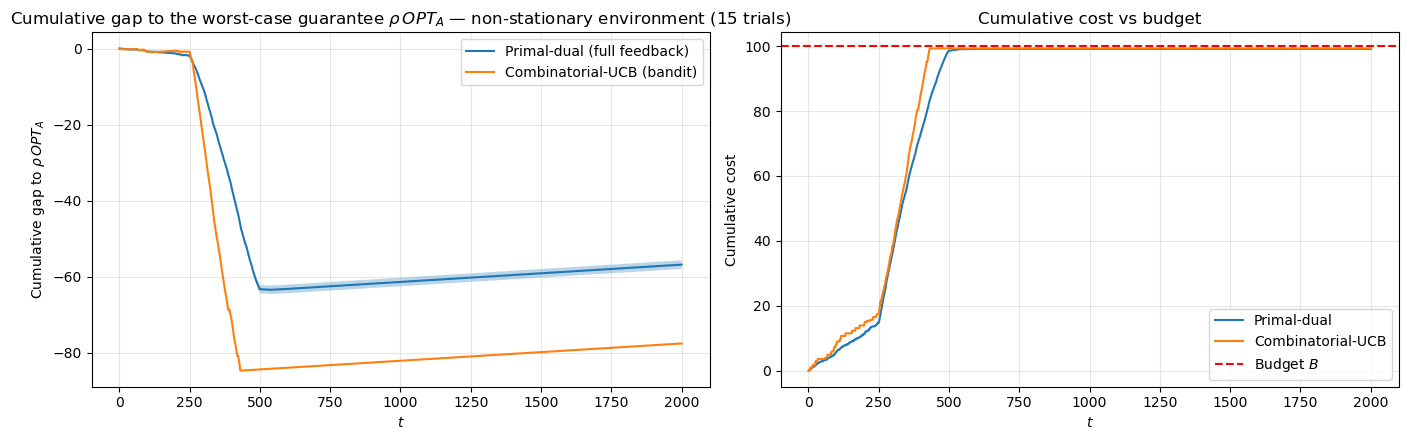

Non-stationary env — final avg gap to rho*OPT_A: PD = -56.86, C-UCB = -77.60
Non-stationary env — final avg std regret vs OPT_A: PD = 116.08, C-UCB = 95.34
Non-stationary env — final average cost:   PD = 99.15, C-UCB = 99.30  (B = 100)


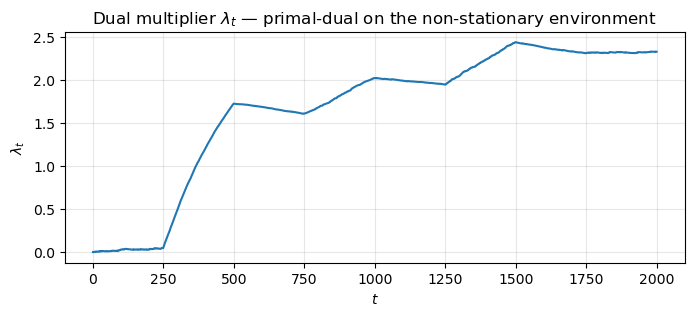

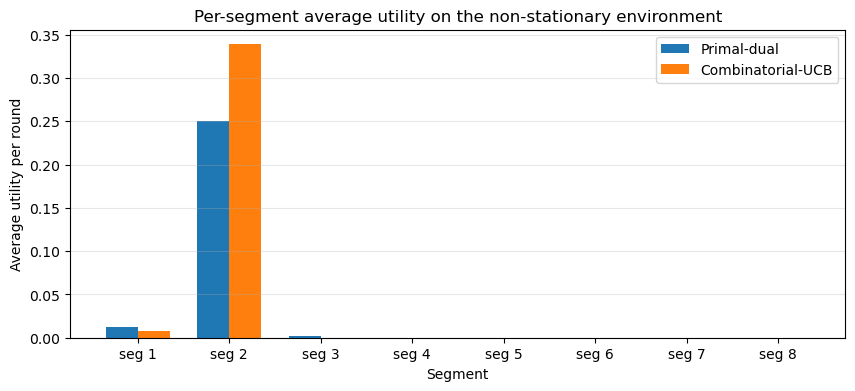

Budget depletion round per trial (None = budget never exhausted):
  PD:    [477, 491, 527, 497, 500, None, 519, None, 535, 538, 484, None, 458, 496, 587]
  C-UCB: [431, 431, 431, 431, 431, 431, 431, 431, 431, 431, 431, 431, 431, 431, 431]


In [10]:
# ============================================================
# Experiment 2: highly non-stationary environment
# ============================================================
m_ns = nonstationary_competing_bids(seed=123, n_competitors=n_competitors,
                                    T=T, segment_scales=segment_scales)

gamma_a, OPT_A = adversarial_clairvoyant(m_ns, super_arms, my_valuations,
                                         available_bids, bid_to_index, rho)
benchmark_A = rho * OPT_A
print("OPT_A (per-round, in hindsight):", OPT_A)
print("Per-round worst-case benchmark rho*OPT_A:", benchmark_A)

n_trials_ns = 15

pd_gap_ns = []
pd_cost_ns = []
ucb_gap_ns = []
ucb_cost_ns = []
pd_utils_ns = []
ucb_utils_ns = []
pd_last = None

for trial in range(n_trials_ns):
    np.random.seed(1000 + trial)          # same m sequence, different algorithm randomness

    # --- primal-dual (full feedback) ---
    pd = PrimalDualAgent(super_arms, empty_idx, T, B)
    u_pd = np.zeros(T)
    c_pd = np.zeros(T)
    for t in range(T):
        a = pd.pull_arm()
        f_vec, c_vec = super_arm_fc(m_ns[:, t], super_arms, my_valuations,
                                    available_bids, bid_to_index)
        pd.update(f_vec, c_vec, a)
        u_pd[t] = f_vec[a]
        c_pd[t] = c_vec[a]
    pd_gap_ns.append(np.cumsum(benchmark_A - u_pd))
    pd_cost_ns.append(np.cumsum(c_pd))
    pd_utils_ns.append(u_pd)
    pd_last = pd

    # --- combinatorial-UCB (bandit feedback) ---
    np.random.seed(1000 + trial)
    ucba = CombinatorialUCBAgent(super_arms, empty_idx, bid_to_index,
                                 n_campaigns, n_bids, my_valuations, T, B)
    u_ucb = np.zeros(T)
    c_ucb = np.zeros(T)
    for t in range(T):
        a = ucba.pull_arm()
        S, bids = super_arms[a]
        if S:
            win = available_bids[None, :] >= m_ns[:, t, None]
            rew_t = (my_valuations[:, None] - available_bids[None, :]) * win
            cost_t = available_bids[None, :] * win
            f_list = [rew_t[i, bid_to_index[round(b, 8)]] for i, b in zip(S, bids)]
            c_list = [cost_t[i, bid_to_index[round(b, 8)]] for i, b in zip(S, bids)]
        else:
            f_list, c_list = [], []
        ucba.update(S, bids, f_list, c_list)
        u_ucb[t] = sum(f_list)
        c_ucb[t] = sum(c_list)
    ucb_gap_ns.append(np.cumsum(benchmark_A - u_ucb))
    ucb_cost_ns.append(np.cumsum(c_ucb))
    ucb_utils_ns.append(u_ucb)

pd_gap_ns = np.array(pd_gap_ns)
pd_cost_ns = np.array(pd_cost_ns)
ucb_gap_ns = np.array(ucb_gap_ns)
ucb_cost_ns = np.array(ucb_cost_ns)
pd_utils_ns = np.array(pd_utils_ns)
ucb_utils_ns = np.array(ucb_utils_ns)

# standard regret w.r.t. OPT_A (in addition to the gap to rho*OPT_A)
pd_regret_ns = np.cumsum(OPT_A - pd_utils_ns, axis=1)
ucb_regret_ns = np.cumsum(OPT_A - ucb_utils_ns, axis=1)

plot_curves(pd_gap_ns, ucb_gap_ns, pd_cost_ns, ucb_cost_ns,
            f"Cumulative gap to the worst-case guarantee $\\rho\\,OPT_A$ — non-stationary environment ({n_trials_ns} trials)",
            n_trials_ns, ylabel="Cumulative gap to $\\rho\\,OPT_A$")

print(f"Non-stationary env — final avg gap to rho*OPT_A: PD = {pd_gap_ns.mean(axis=0)[-1]:.2f}, "
      f"C-UCB = {ucb_gap_ns.mean(axis=0)[-1]:.2f}")
print(f"Non-stationary env — final avg std regret vs OPT_A: PD = {pd_regret_ns.mean(axis=0)[-1]:.2f}, "
      f"C-UCB = {ucb_regret_ns.mean(axis=0)[-1]:.2f}")
print(f"Non-stationary env — final average cost:   PD = {pd_cost_ns.mean(axis=0)[-1]:.2f}, "
      f"C-UCB = {ucb_cost_ns.mean(axis=0)[-1]:.2f}  (B = {B})")

# lambda trajectory of the last primal-dual trial
plt.figure(figsize=(8, 3))
plt.plot(pd_last.lmbd_history)
plt.xlabel("$t$"); plt.ylabel("$\\lambda_t$")
plt.title("Dual multiplier $\\lambda_t$ — primal-dual on the non-stationary environment")
plt.grid(alpha=0.3); plt.show()

# --- Per-segment analysis: how each agent uses the budget across segments ---
seg_len = T // n_segments
pd_seg = pd_utils_ns.reshape(n_trials_ns, n_segments, seg_len).mean(axis=(0, 2))
ucb_seg = ucb_utils_ns.reshape(n_trials_ns, n_segments, seg_len).mean(axis=(0, 2))

x = np.arange(n_segments)
width = 0.35
plt.figure(figsize=(10, 4))
plt.bar(x - width / 2, pd_seg, width, label="Primal-dual")
plt.bar(x + width / 2, ucb_seg, width, label="Combinatorial-UCB")
plt.xticks(x, [f"seg {s + 1}" for s in x])
plt.xlabel("Segment")
plt.ylabel("Average utility per round")
plt.title("Per-segment average utility on the non-stationary environment")
plt.legend()
plt.grid(alpha=0.3, axis="y")
plt.show()

def depletion_round(cum_cost, B):
    """First round in which the budget is (almost) exhausted; None if never."""
    idx = np.argwhere(cum_cost >= B - 1)
    return idx[0, 0] + 1 if idx.size else None

# NOTE: pd_cost_ns / ucb_cost_ns already contain CUMULATIVE costs
pd_dep = [depletion_round(cum, B) for cum in pd_cost_ns]
ucb_dep = [depletion_round(cum, B) for cum in ucb_cost_ns]
print("Budget depletion round per trial (None = budget never exhausted):")
print("  PD:   ", pd_dep)
print("  C-UCB:", ucb_dep)

## Best-of-both-worlds summary

The key claim of Requirement 3 is that **one** primal-dual algorithm (same hyperparameters, no tuning per environment) behaves well in **both** environments:

- **Stochastic**: regret vs the LP clairvoyant $OPT_S$ is small ($R_{2000} \approx 17$) and $R_T/T$ decreases with $T$ ($0.0107 \to 0.0074$ for $T = 500 \to 4000$), consistent with the theoretical $\tilde O(\sqrt{T})$ guarantee. On the same instance, C-UCB's $R_T/T$ stays roughly constant ($\approx 0.015$), i.e., its regret grows roughly linearly.
- **Highly non-stationary / adversarial**: the primal-dual method exceeds the worst-case guarantee $\rho\,OPT_A$ on this instance (gap $= -56.9$, i.e., utility $\approx 66$ against a guarantee of $\approx 9$). No algorithm can *guarantee* more than a $\rho$ fraction of $OPT_A$ in the worst case.

**Honest reading of the non-stationary comparison.** With the fixed-$\rho$ course algorithm, both agents exhaust the budget early (C-UCB at round $\approx 431$ in every trial, PD at $\approx 460$-$590$ in most trials), because the early segments contain very profitable, cheap auctions. C-UCB front-loads more aggressively and happens to extract more utility on this particular sequence ($86.7$ vs $66.0$). This is instance behaviour, not a contradiction of the theory: the guarantee is about exceeding $\rho\,OPT_A$, not about dominating a specific baseline on a single sequence. What the experiments do show is that (i) the full-feedback primal-dual method is the one with clearly sublinear stochastic regret, and (ii) it comfortably exceeds the adversarial worst-case guarantee with the *same* algorithm and hyperparameters.

### How to read the numbers

- **Negative "gap" in the non-stationary table is not an error.** The benchmark is the *worst-case* guarantee $\rho\,OPT_A$ (here $0.05 \times OPT_A$). On this particular sequence both agents do better than that guarantee, so the gap is negative. It does **not** mean we beat the in-hindsight optimum $OPT_A$ itself; the standard regret w.r.t. $OPT_A$ (also reported) is positive.
- **Both agents spend essentially the whole budget** ($\approx 99/100$) in both environments; the budget is a *cap* and it is respected (no trial overspends).
- **The comparison is not apples-to-apples in feedback**: the primal-dual agent uses full feedback (allowed by Requirement 3), while C-UCB uses bandit feedback (as in Requirement 2). This is intentional and should be stated in the presentation.
- **Per-segment view.** The per-segment plot and the depletion table show that on this non-stationary sequence both agents earn mainly in the first segments, until the budget is exhausted; afterwards they bid nothing. This front-loading is driven by the cheap, very profitable early segments, and is exactly the behaviour that a change-detection / sliding-window extension (Requirement 4) would need to address.
- **Implementation notes.** The agent follows Lecture 8's pacing strategy: fixed $\rho = B/T$, $\lambda_0 = 0$, OGD on the dual with the full-feedback expected cost (Practical 08). Two practical details are explicit: per-round min-max normalization of the Hedge losses (fixed worst-case bounds would slow learning by orders of magnitude), and an affordability safeguard because a super-arm's payment can exceed 1. The formal $\tilde O(\sqrt T)$ / $\rho T OPT_A - \tilde O(\sqrt T)$ guarantees apply to the canonical algorithm with fixed bounded losses.

In [11]:
# ============================================================
# Metric table (T = 2000, B = 100; averages over trials)
# ============================================================
def show(label, pd_val, cb_val):
    print(f"{label:<34}{pd_val:>12.2f}{cb_val:>12.2f}")

print("=" * 60)
print("Stochastic environment")
print("=" * 60)
show("Regret vs OPT_S (T*OPT_S - utility)", pd_regret_stoch.mean(axis=0)[-1], ucb_regret_stoch.mean(axis=0)[-1])
show("Total utility", (OPT_S * T - pd_regret_stoch.mean(axis=0)[-1]), (OPT_S * T - ucb_regret_stoch.mean(axis=0)[-1]))
show("Total cost", pd_cost_stoch.mean(axis=0)[-1], ucb_cost_stoch.mean(axis=0)[-1])

print()
print("=" * 60)
print("Highly non-stationary environment")
print("=" * 60)
show("Gap to worst-case guarantee (rho*T*OPT_A - utility)", pd_gap_ns.mean(axis=0)[-1], ucb_gap_ns.mean(axis=0)[-1])
show("Standard regret vs OPT_A (T*OPT_A - utility)", pd_regret_ns.mean(axis=0)[-1], ucb_regret_ns.mean(axis=0)[-1])
show("Total utility", (benchmark_A * T - pd_gap_ns.mean(axis=0)[-1]), (benchmark_A * T - ucb_gap_ns.mean(axis=0)[-1]))
show("Total cost", pd_cost_ns.mean(axis=0)[-1], ucb_cost_ns.mean(axis=0)[-1])
show("Utility fraction of T*OPT_A", (benchmark_A * T - pd_gap_ns.mean(axis=0)[-1]) / (OPT_A * T),
     (benchmark_A * T - ucb_gap_ns.mean(axis=0)[-1]) / (OPT_A * T))

Stochastic environment
Regret vs OPT_S (T*OPT_S - utility)       17.20       30.18
Total utility                            28.69       15.71
Total cost                               99.22       99.24

Highly non-stationary environment
Gap to worst-case guarantee (rho*T*OPT_A - utility)      -56.86      -77.60
Standard regret vs OPT_A (T*OPT_A - utility)      116.08       95.34
Total utility                            65.96       86.70
Total cost                               99.15       99.30
Utility fraction of T*OPT_A               0.36        0.48
